In [10]:
from google.colab import files

uploaded = files.upload()

Saving SALES_FORECASTING.webp to SALES_FORECASTING (1).webp
Saving train.csv to train (1).csv


In [11]:
import os

print("Uploaded files:")
for file in uploaded.keys():
    print(file)

Uploaded files:
SALES_FORECASTING (1).webp
train (1).csv


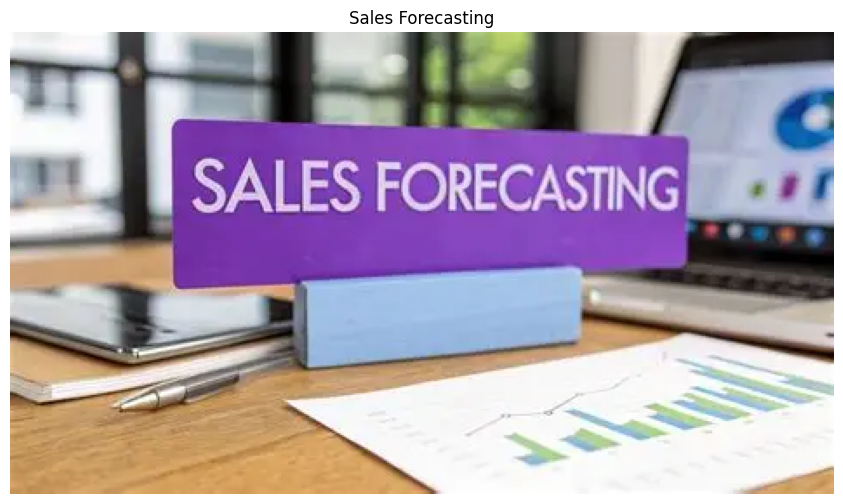

In [12]:
from PIL import Image
import matplotlib.pyplot as plt

image_path = next(iter(uploaded.keys()))

img = Image.open(image_path)

plt.figure(figsize=(12, 6))
plt.imshow(img)
plt.axis("off")
plt.title("Sales Forecasting")
plt.show()

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

# UPLOAD DATASET
# FIRST FIVE ROWS

In [ ]:
df = pd.read_csv('/content/train.csv')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


# UNDERSTAND DATASET

In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 9800
Columns: 18


In [ ]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']


# MISSING VALUE

In [ ]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


# DUPLICATE VALUE

In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
df = df.drop_duplicates()

# CONVERTING DATE COLUMN

In [ ]:
df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    dayfirst=True
)

# MONTHLY SALES TIME SERIES

In [ ]:
df[['Order Date', 'Sales']].head()

,Order Date,Sales
0,2017-11-08,261.9600
1,2017-11-08,731.9400
2,2017-06-12,14.6200
3,2016-10-11,957.5775
4,2016-10-11,22.3680


In [ ]:
monthly_sales = (
    df.set_index('Order Date')
      .resample('MS')['Sales']
      .sum()
)

In [ ]:
monthly_sales.head()

,Sales
Order Date,
2015-01-01,14205.707
2015-02-01,4519.892
2015-03-01,55205.797
2015-04-01,27906.855
2015-05-01,23644.303


# HISTORICAL MONTHLY SALES

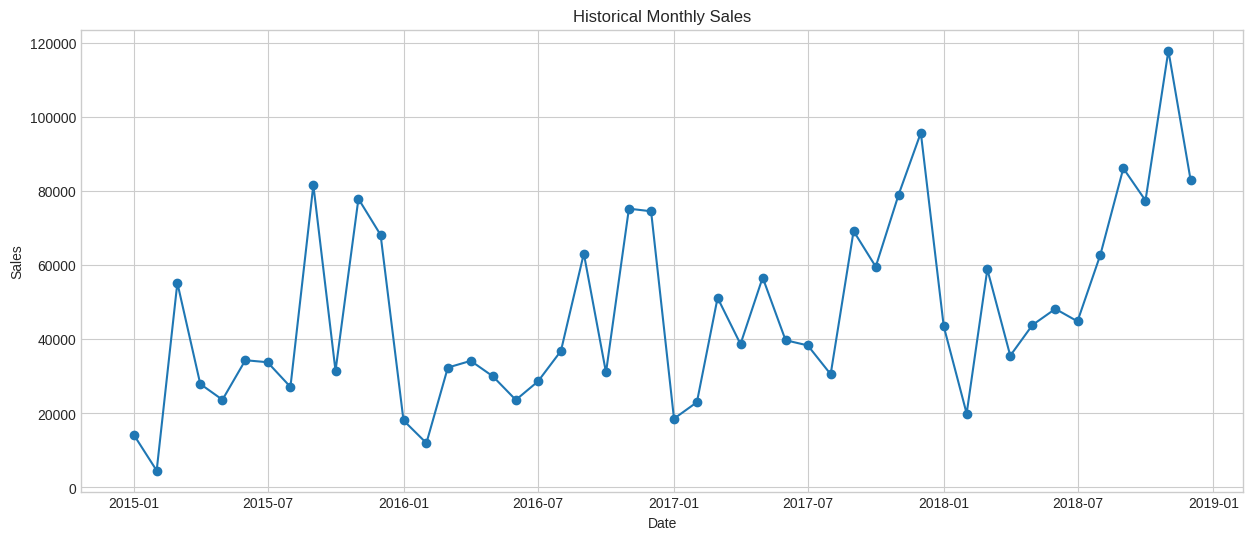

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o'
)

plt.title('Historical Monthly Sales')
plt.xlabel('Date')
plt.ylabel('Sales')

plt.show()

# SALES TREND ANALYSIS

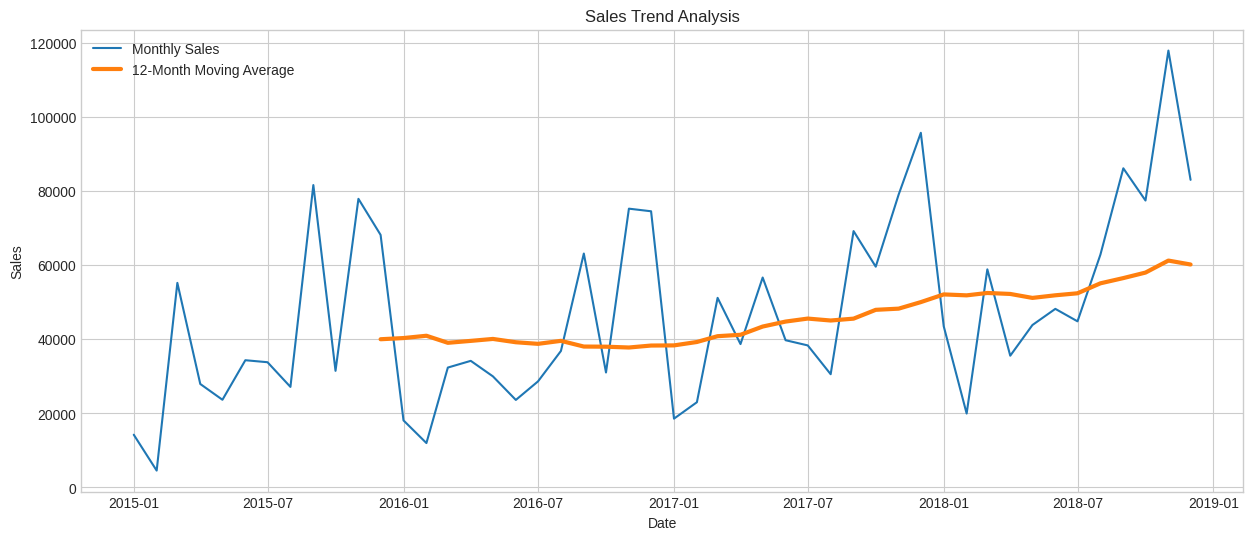

In [ ]:
rolling_sales = monthly_sales.rolling(
    window=12
).mean()

plt.figure(figsize=(15,6))

plt.plot(
    monthly_sales,
    label='Monthly Sales'
)

plt.plot(
    rolling_sales,
    label='12-Month Moving Average',
    linewidth=3
)

plt.title('Sales Trend Analysis')
plt.xlabel('Date')
plt.ylabel('Sales')

plt.legend()

plt.show()

# SEASONAL ANALYSIS

<Figure size 1500x1000 with 0 Axes>

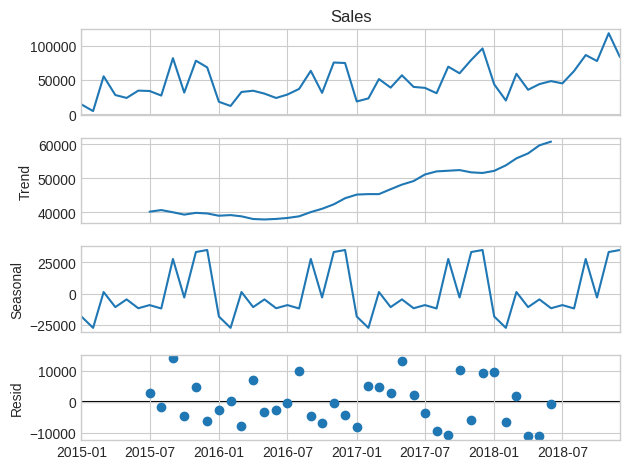

In [ ]:
decomposition = seasonal_decompose(
    monthly_sales,
    model='additive',
    period=12
)

fig = decomposition.plot()
fig.set_size_inches(15, 10)
plt.show()

# MONTHLY SEASONAL PATTERN

In [ ]:
df['Month'] = df['Order Date'].dt.month

monthly_pattern = (
    df.groupby('Month')['Sales']
      .sum()
)

monthly_pattern

,Sales
Month,
1,94291.6296
2,59371.1154
3,197573.5872
4,136283.0006
5,154086.7237
6,145837.5233
7,145535.6890
8,157315.9270
9,300103.4117


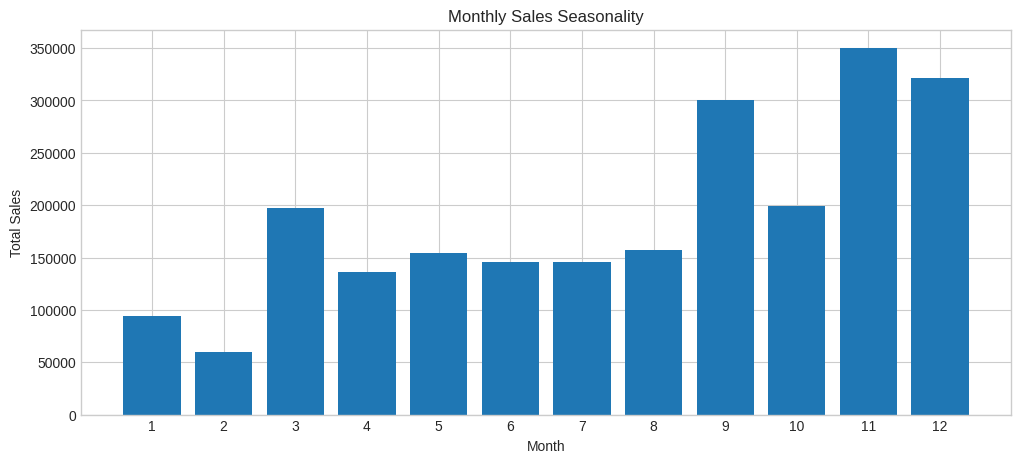

In [ ]:
plt.figure(figsize=(12,5))

plt.bar(
    monthly_pattern.index,
    monthly_pattern.values
)

plt.title('Monthly Sales Seasonality')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.xticks(range(1,13))

plt.show()

# POTENTIAL HIGH DEMAND PERIODS

In [ ]:
sales_mean = monthly_sales.mean()
sales_std = monthly_sales.std()

high_sales_threshold = sales_mean + sales_std

potential_promo_months = monthly_sales[
    monthly_sales > high_sales_threshold
]

print("Potential high-demand periods:")
print(potential_promo_months)

Potential high-demand periods:
Order Date
2015-09-01     81623.5268
2015-11-01     77907.6607
2016-11-01     75249.3995
2016-12-01     74543.6012
2017-11-01     79066.4958
2017-12-01     95739.1210
2018-09-01     86152.8880
2018-10-01     77448.1312
2018-11-01    117938.1550
2018-12-01     83030.3888
Name: Sales, dtype: float64


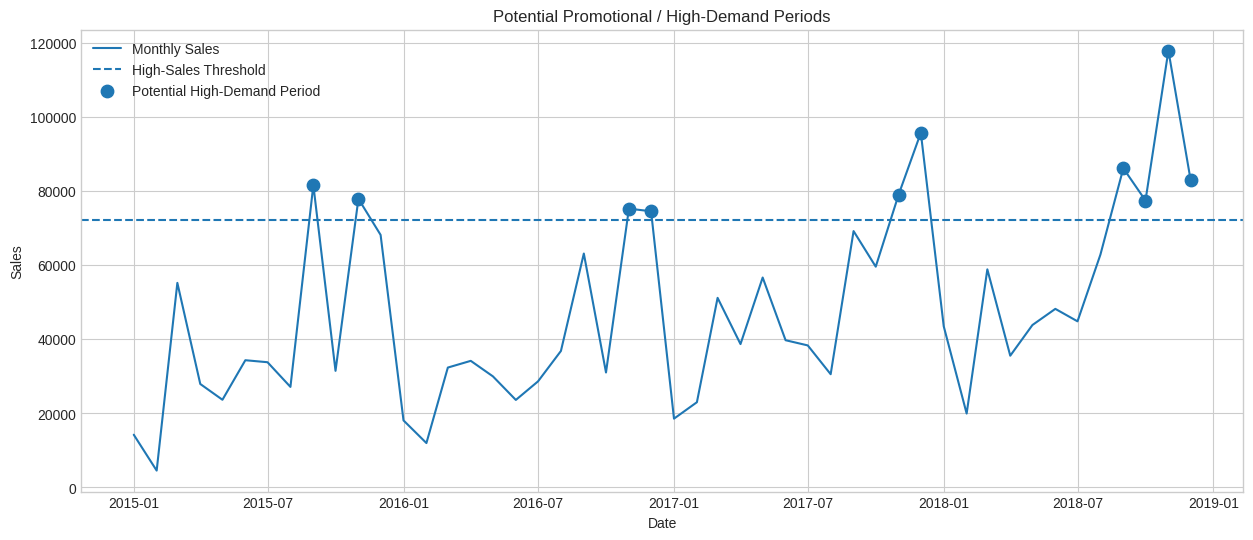

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_sales,
    label='Monthly Sales'
)

plt.axhline(
    high_sales_threshold,
    linestyle='--',
    label='High-Sales Threshold'
)

plt.scatter(
    potential_promo_months.index,
    potential_promo_months.values,
    s=80,
    label='Potential High-Demand Period'
)

plt.title('Potential Promotional / High-Demand Periods')
plt.xlabel('Date')
plt.ylabel('Sales')

plt.legend()

plt.show()

In [ ]:
adf_result = adfuller(monthly_sales)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF Statistic: -4.416136761430769
p-value: 0.00027791039276670623


In [ ]:
sales_diff = monthly_sales.diff().dropna()

In [ ]:
adf_result_diff = adfuller(sales_diff)

print("ADF Statistic:", adf_result_diff[0])
print("p-value:", adf_result_diff[1])

ADF Statistic: -8.727061830353268
p-value: 3.2669175472796045e-14


# TRAIN AND TEST DATASET

In [ ]:
train = monthly_sales.iloc[:-12]
test = monthly_sales.iloc[-12:]

print("Training data:", len(train))
print("Testing data:", len(test))

Training data: 36
Testing data: 12


# SARIMA MODEL

In [ ]:
model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit = model.fit()

print(model_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   36
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 -96.483
Date:                            Thu, 13 Aug 2026   AIC                            202.966
Time:                                    13:20:07   BIC                            203.952
Sample:                                01-01-2015   HQIC                           200.838
                                     - 12-01-2017                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2270      0.644     -0.352      0.725      -1.489       1.035
ma.L1         -0.9915      0.829   

# ACTUAL VS PREDICTED FORECAST

In [ ]:
forecast_result = model_fit.get_forecast(
    steps=len(test)
)

forecast = forecast_result.predicted_mean

confidence_interval = forecast_result.conf_int()

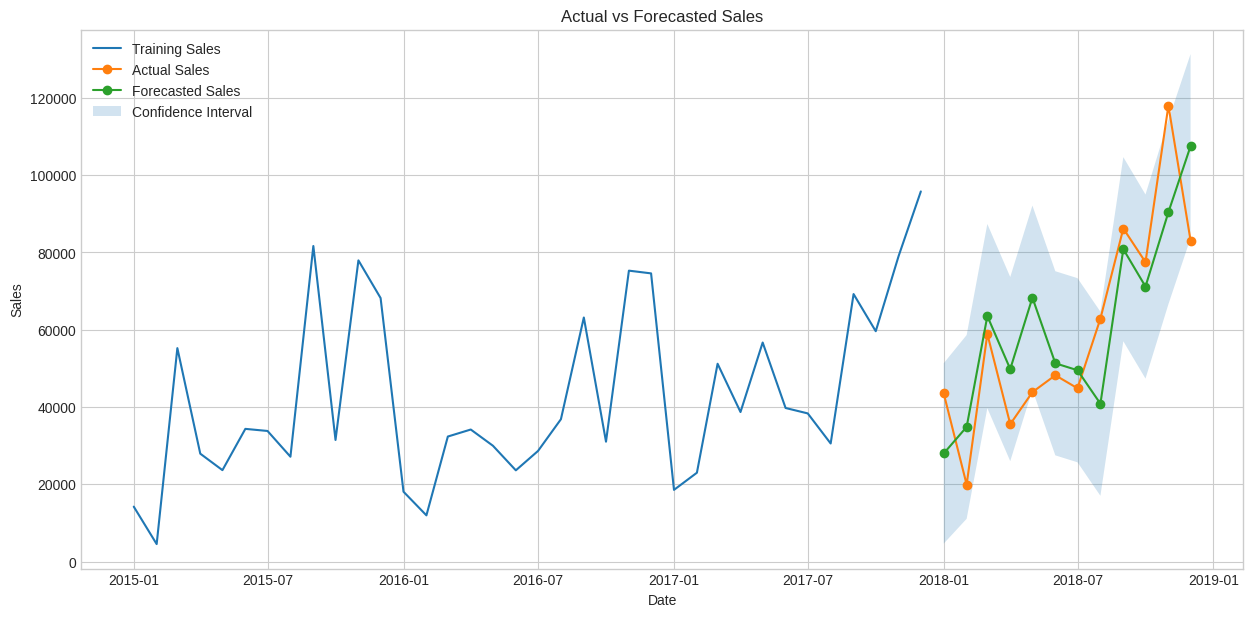

In [ ]:
plt.figure(figsize=(15,7))

plt.plot(
    train.index,
    train,
    label='Training Sales'
)

plt.plot(
    test.index,
    test,
    marker='o',
    label='Actual Sales'
)

plt.plot(
    test.index,
    forecast,
    marker='o',
    label='Forecasted Sales'
)

plt.fill_between(
    test.index,
    confidence_interval.iloc[:,0],
    confidence_interval.iloc[:,1],
    alpha=0.2,
    label='Confidence Interval'
)

plt.title('Actual vs Forecasted Sales')
plt.xlabel('Date')
plt.ylabel('Sales')

plt.legend()

plt.show()

# EVALUATION METRICS

In [ ]:
mae = mean_absolute_error(
    test,
    forecast
)

print("MAE:", mae)

MAE: 13930.017297227341


In [ ]:
rmse = np.sqrt(
    mean_squared_error(
        test,
        forecast
    )
)

print("RMSE:", rmse)

In [ ]:
mape = np.mean(
    np.abs(
        (test - forecast) / test
    )
) * 100

print("MAPE:", mape)

MAPE: 27.7680896334966


In [ ]:
rmse = np.sqrt(
    mean_squared_error(
        test,
        forecast
    )
)

evaluation = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'MAPE'],
    'Value': [mae, rmse, mape]
})

evaluation

,Metric,Value
0,MAE,13930.017297
1,RMSE,16394.816726
2,MAPE,27.768090


In [ ]:
final_model = SARIMAX(
    monthly_sales,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_model_fit = final_model.fit()

In [ ]:
future_result = final_model_fit.get_forecast(
    steps=12
)

future_forecast = future_result.predicted_mean

future_confidence = future_result.conf_int()

# FITURE SALES FORECAST

In [ ]:
future_sales = pd.DataFrame({
    'Month': future_forecast.index,
    'Forecast Sales': future_forecast.values,
    'Lower Bound': future_confidence.iloc[:,0].values,
    'Upper Bound': future_confidence.iloc[:,1].values
})

future_sales = future_sales.round(2)

future_sales

,Month,Forecast Sales,Lower Bound,Upper Bound
0,2019-01-01,46782.48,16992.67,76572.28
1,2019-02-01,40285.47,9596.04,70974.90
2,2019-03-01,72234.20,41318.86,103149.55
3,2019-04-01,57236.03,26161.99,88310.07
4,2019-05-01,66910.83,35688.42,98133.24
5,2019-06-01,61378.25,30009.64,92746.87
6,2019-07-01,60193.67,28679.73,91707.62
7,2019-08-01,64798.24,33139.62,96456.86
8,2019-09-01,95640.89,63838.19,127443.58
9,2019-10-01,81551.12,49604.93,113497.31


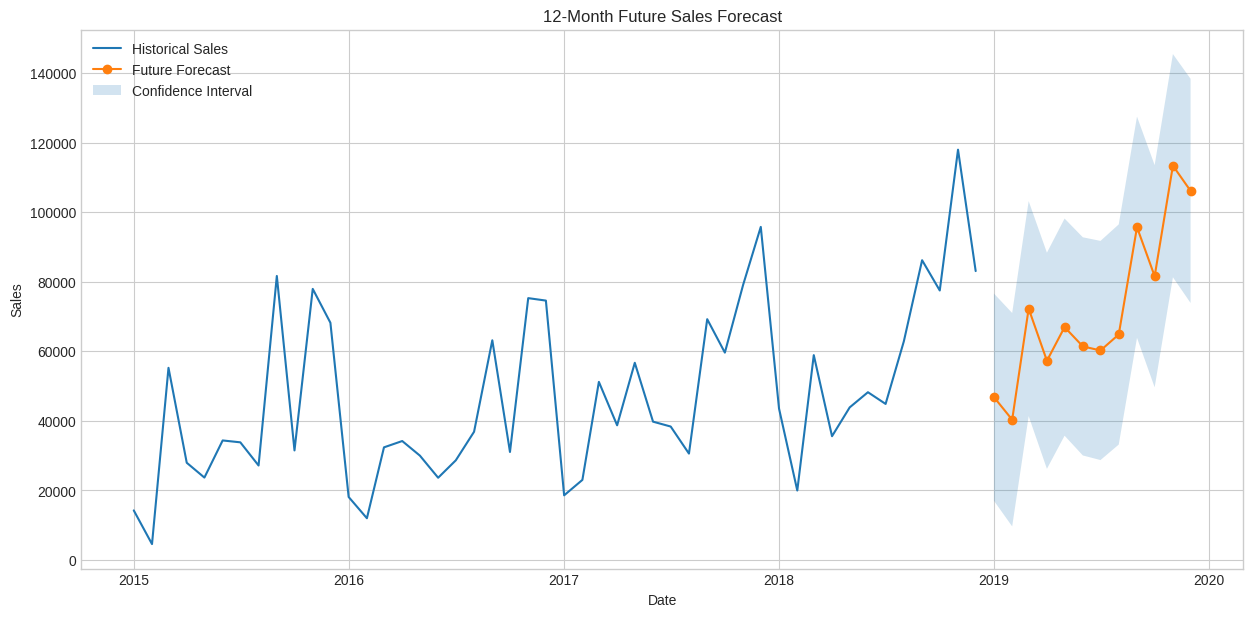

In [ ]:
plt.figure(figsize=(15,7))

plt.plot(
    monthly_sales.index,
    monthly_sales,
    label='Historical Sales'
)

plt.plot(
    future_forecast.index,
    future_forecast,
    marker='o',
    label='Future Forecast'
)

plt.fill_between(
    future_forecast.index,
    future_confidence.iloc[:,0],
    future_confidence.iloc[:,1],
    alpha=0.2,
    label='Confidence Interval'
)

plt.title('12-Month Future Sales Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')

plt.legend()

plt.show()

In [ ]:
future_sales.to_csv(
    '/content/sales_forecast_12_months.csv',
    index=False
)

evaluation.to_csv(
    '/content/model_evaluation.csv',
    index=False
)

print("Files saved successfully.")

Files saved successfully.


# CONCLUSION

## The SARIMA model successfully forecasted future sales by capturing historical trends and seasonal patterns. The results demonstrate how time series forecasting can support better inventory planning, sales strategy, and data-driven business decisions.